In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datetime import date
import matplotlib.pyplot as plt
from modo_energy_client.modo_energy_api_client import ModoEnergyAPIClient


In [3]:
client = ModoEnergyAPIClient(cache_requests=True)

In [4]:
start_date = date(2024, 7, 1)
end_date = date(2026, 5, 31)

In [8]:
# Group by the month of the 'date' column
ercot_bess["month"] = ercot_bess["date"].dt.to_period("M").dt.to_timestamp()
ercot_bess_monthly = (
    ercot_bess.groupby("month")
    .agg({"total_energy_capacity_mwh": "mean", "total_rated_power_mw": "mean"})
    .reset_index()
)

In [9]:
ercot_bess_monthly

,month,total_energy_capacity_mwh,total_rated_power_mw
0,2024-07-01,259.651667,171.197667
1,2024-08-01,251.943548,166.313871
2,2024-09-01,274.507812,176.179062
3,2024-10-01,303.735937,199.625937
4,2024-11-01,337.439394,223.725152
5,2024-12-01,338.039394,224.325152
6,2025-01-01,333.611111,223.200833
7,2025-02-01,334.013889,223.475833
8,2025-03-01,322.223684,214.685000
9,2025-04-01,304.978049,202.334390


In [8]:
fuel_mix_raw = client.get_ercot_generation_fuel_mix(
    date_from=start_date, date_to=end_date
)

Fetching pages : 23page [00:10,  2.23page/s]


In [11]:
fuel_mix = fuel_mix_raw.drop(["settlementType", "repeated_hour_flag"], axis=1)
fuel_mix["powerStorage"] = fuel_mix["powerStorage"].clip(
    lower=0
)  # powerStorage can be negative, but we want to focus on the energy being stored in batteries, so we clip it at 0
fuel_mix_resampled = fuel_mix.resample("ME").sum()
fuel_mix_resampled = fuel_mix_resampled.astype("int")

In [12]:
fuel_mix_resampled["total"] = fuel_mix_resampled.sum(axis=1)

In [17]:
fuel_mix_resampled

,coalAndLignite,hydro,nuclear,other,powerStorage,solar,wind,naturalGas,total
timestamp,,,,,,,,,
2024-07-31 00:00:00+00:00,78535546,420467,44599723,494066,2145446,66637942,105334368,283806151,581973709
2024-08-31 00:00:00+00:00,83568096,352930,47024968,628917,2625779,75245636,99284621,335265506,643996453
2024-09-30 00:00:00+00:00,78537404,252086,46461062,219894,2582961,62735769,77254317,267744645,535788138
2024-10-31 00:00:00+00:00,67091368,197345,33128883,414312,3391495,62780978,123071849,225265896,515342126
2024-11-30 00:00:00+00:00,58528979,338884,35094774,303883,3543537,45395831,129121134,170294076,442621098
2024-12-31 00:00:00+00:00,71025230,324462,49339304,614963,4086989,39032012,119539345,174570606,458532911
2025-01-31 00:00:00+00:00,85013602,465962,49443437,716170,4384875,43077715,124809003,223382362,531293126
2025-02-28 00:00:00+00:00,62534286,331422,44539297,497394,4258224,47580157,116116554,180013471,455870805
2025-03-31 00:00:00+00:00,55319914,259159,49147777,429808,5120030,66852941,156241642,124359597,457730868


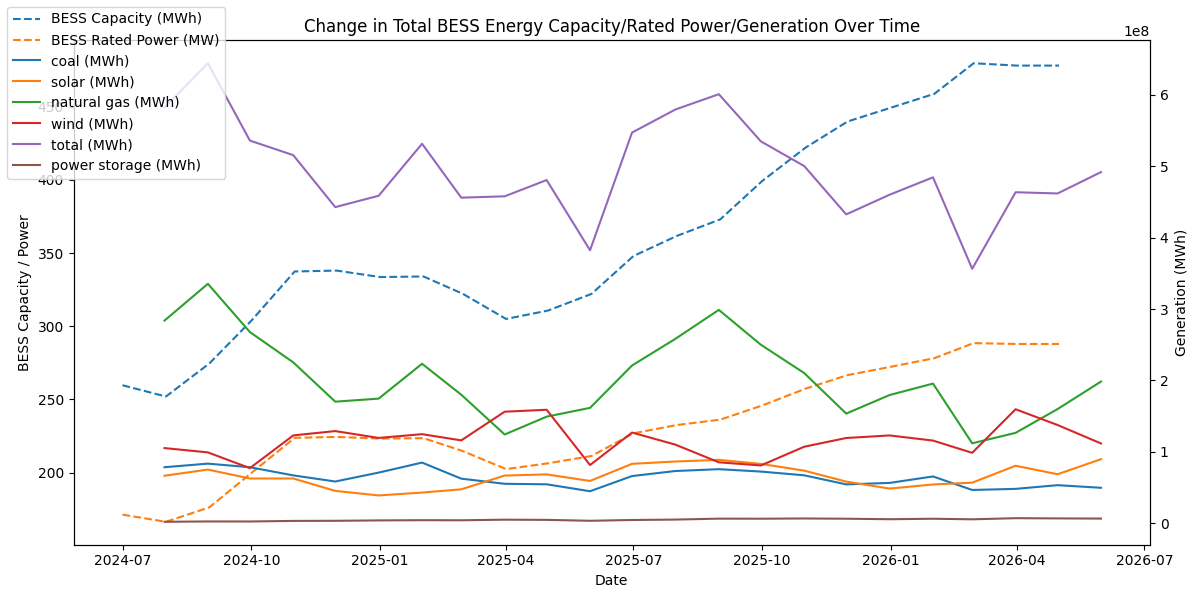

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(
    ercot_bess_monthly["month"],
    ercot_bess_monthly["total_energy_capacity_mwh"],
    label="BESS Capacity (MWh)",
    linestyle="--",
)
ax1.plot(
    ercot_bess_monthly["month"],
    ercot_bess_monthly["total_rated_power_mw"],
    label="BESS Rated Power (MW)",
    linestyle="--",
)
ax1.set_xlabel("Date")
ax1.set_ylabel("BESS Capacity / Power")
ax1.set_title("Change in Total BESS Energy Capacity/Rated Power/Generation Over Time")
ax2 = ax1.twinx()

ax2.plot(
    fuel_mix_resampled.index,
    fuel_mix_resampled["coalAndLignite"],
    label="coal (MWh)",
    # color="black",
)

ax2.plot(
    fuel_mix_resampled.index,
    fuel_mix_resampled["solar"],
    label="solar (MWh)",
    #  color="yellow",
)

ax2.plot(
    fuel_mix_resampled.index,
    fuel_mix_resampled["naturalGas"],
    label="natural gas (MWh)",
    # color="yellow",
)
ax2.plot(
    fuel_mix_resampled.index,
    fuel_mix_resampled["wind"],
    label="wind (MWh)",
    # color="yellow",
)


ax2.plot(
    fuel_mix_resampled.index,
    fuel_mix_resampled["total"],
    label="total (MWh)",
    # color="yellow",
)

ax2.plot(
    fuel_mix_resampled.index,
    fuel_mix_resampled["powerStorage"],
    label="power storage (MWh)",
    # color="yellow",
)

ax2.set_ylabel("Generation (MWh)")
fig.tight_layout()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.show()